# Proyek Analisis Data: [Input Nama Dataset]

- **Nama:** Arya Gunavaro Goberto
- **Email:** cdcc208d6y1028@student.devacademy.id
- **ID Dicoding:** CDCC208D6Y1028


## Menentukan Pertanyaan Bisnis


1. Bagaimana pola rata-rata penggunaan sepeda berdasarkan jam?
2. Apakah rata-rata penggunaan sepeda lebih tinggi pada hari kerja atau hari libur?
3. Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda?
4. Mana yang lebih dominan: pengguna casual atau registered?


## Import Semua Packages/Library yang Digunakan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling


### Gathering Data


In [2]:
day_df = pd.read_csv('data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv('data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**

1. day_df memiiki 731 baris dan 16 kolom
2. hour_df memiliki 17379 baris dan 17 kolom. hour_df lebih detail dikarenakan ada tambahan kolom hr
3. Kedua dataseet didominasi oleh tipe data int64, float64, dan object


### Assessing Data


In [6]:
day_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [7]:
print(f"Duplikasi data: {day_df.duplicated().sum()}")

Duplikasi data: 0


In [8]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
print(f"Duplikasi data: {hour_df.duplicated().sum()}")

Duplikasi data: 0


In [10]:
for col in ['temp', 'atemp', 'hum', 'windspeed', 'cnt']:
    Q1 = hour_df[col].quantile(0.25)
    Q3 = hour_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = hour_df[(hour_df[col] < lower) | (hour_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

temp: 0 outliers
atemp: 0 outliers
hum: 22 outliers
windspeed: 342 outliers
cnt: 505 outliers


In [11]:
for col in ['temp', 'atemp', 'hum', 'windspeed', 'cnt']:
    Q1 = day_df[col].quantile(0.25)
    Q3 = day_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = day_df[(day_df[col] < lower) | (day_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

temp: 0 outliers
atemp: 0 outliers
hum: 2 outliers
windspeed: 13 outliers
cnt: 0 outliers


**Insight:**

- Untuk data hour_df dan hour_df sudah bersih karena tidak terdapat missing values dan data duplikasi
- Pakai metode IQR, tidak ada outlier pada kolom temp dan atemp pada day_df dan hour_df
- Terdapat outlier kecil pada kolom hum pada kedua dataset. day_df (2 data) dan hour_df (22 data). Jumlah ini masih tergolong cukup wajar
- Terdapat outlier besar pada kolom windspeed pada kedua dataset. day_df (13 data) dan hour_df (342 data). Hal ini mungkin bisa terjadi karena variasi data yang lebih tinggi pada hour_df


### Cleaning Data


In [12]:
hour_df.dropna(axis=0, inplace=True)

**Insight:**


In [13]:
day_df.dropna(axis=0, inplace=True)

## Exploratory Data Analysis (EDA)


In [14]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [15]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,NaN,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,NaN,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,NaN,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,NaN,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000


In [16]:
hour_df.groupby('mnth').agg({
    'cnt': ['mean', 'max', 'min']
})

cnt         
            mean  max min
mnth                     
1      94.424773  559   1
2     112.865026  610   1
3     155.410726  957   1
4     187.260960  822   1
5     222.907258  873   1
6     240.515278  900   1
7     231.819892  913   1
8     238.097627  941   1
9     240.773138  977   1
10    222.158511  963   1
11    177.335421  729   1
12    142.303439  759   1

In [17]:
hour_df.groupby('weekday').agg({
    'cnt': 'mean'
})

,cnt
weekday,
0,177.468825
1,183.744655
2,191.238891
3,191.130505
4,196.436665
5,196.135907
6,190.209793


In [18]:
hour_df.groupby('hr').agg({
    'cnt': 'mean'
})

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


In [19]:
hour_df.groupby('weathersit').agg({
    'cnt': 'mean'
})

,cnt
weathersit,
1,204.869272
2,175.165493
3,111.579281
4,74.333333


In [20]:
hour_df.groupby('workingday').agg({
    'casual': 'mean',
    'registered': 'mean'
})

,casual,registered
workingday,,
0,57.441422,123.963910
1,25.561315,167.646439


In [21]:
hour_df.groupby('season').agg({
    'cnt': ['mean', 'sum']
})

cnt         
              mean      sum
season                     
1       111.114569   471348
2       208.344069   918589
3       236.016237  1061129
4       198.868856   841613

In [22]:
hour_df.groupby(['weekday', 'hr']).agg({
    'cnt': 'mean'
})

cnt
weekday hr            
0       0    93.990385
        1    77.432692
        2    61.627451
        3    31.144231
        4     9.362745
...                ...
6       19  239.932692
        20  180.865385
        21  156.000000
        22  139.663462
        23  115.855769

[168 rows x 1 columns]

**Insight:**

1. Data terdiri dari 731 hari pada `day_df` dan 17.379 jam pada `hour_df`, sehingga cukup untuk melihat pola penggunaan harian dan per jam.
2. Variabel `temp`, `atemp`, `hum`, dan `windspeed` sudah dinormalisasi, jadi nilai rata-ratanya perlu dibaca sebagai skala, bukan suhu atau kecepatan angin asli.
3. Rata-rata `cnt` menunjukkan fluktuasi penggunaan yang cukup besar, terutama pada data per jam, yang mengindikasikan adanya jam sibuk tertentu.
4. Pengguna `registered` jauh lebih dominan dibanding `casual` pada kedua dataset.
5. Nilai `weathersit` adalah kode kategori, jadi tidak tepat jika langsung disimpulkan sebagai cuaca cerah tanpa pemetaan kategori.


In [23]:
for col in ['temp', 'atemp', 'hum', 'windspeed', 'cnt']:
    Q1 = hour_df[col].quantile(0.25)
    Q3 = hour_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = hour_df[(hour_df[col] < lower) | (hour_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

temp: 0 outliers
atemp: 0 outliers
hum: 22 outliers
windspeed: 342 outliers
cnt: 505 outliers


## Visualization & Explanatory Analysis


### Pertanyaan 1:


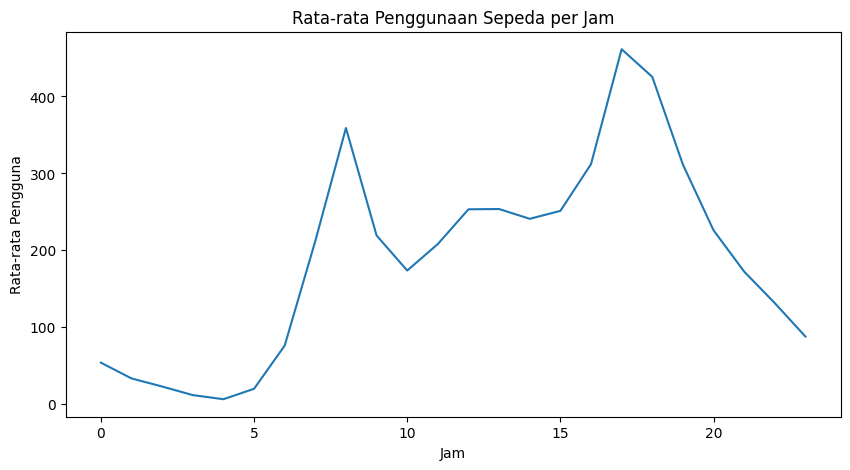

In [24]:
hourly_usage = hour_df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hourly_usage.index, y=hourly_usage.values)
plt.title('Rata-rata Penggunaan Sepeda per Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Pengguna')
plt.show()

### Pertanyaan 2:


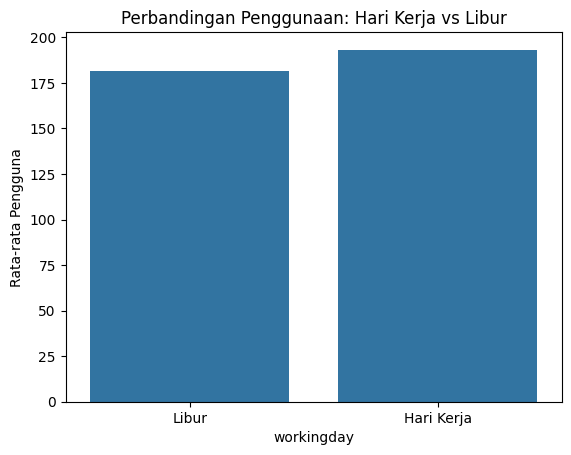

In [25]:
day_usage = hour_df.groupby('workingday')['cnt'].mean()

sns.barplot(x=day_usage.index, y=day_usage.values)
plt.xticks([0,1], ['Libur', 'Hari Kerja'])
plt.title('Perbandingan Penggunaan: Hari Kerja vs Libur')
plt.ylabel('Rata-rata Pengguna')
plt.show()

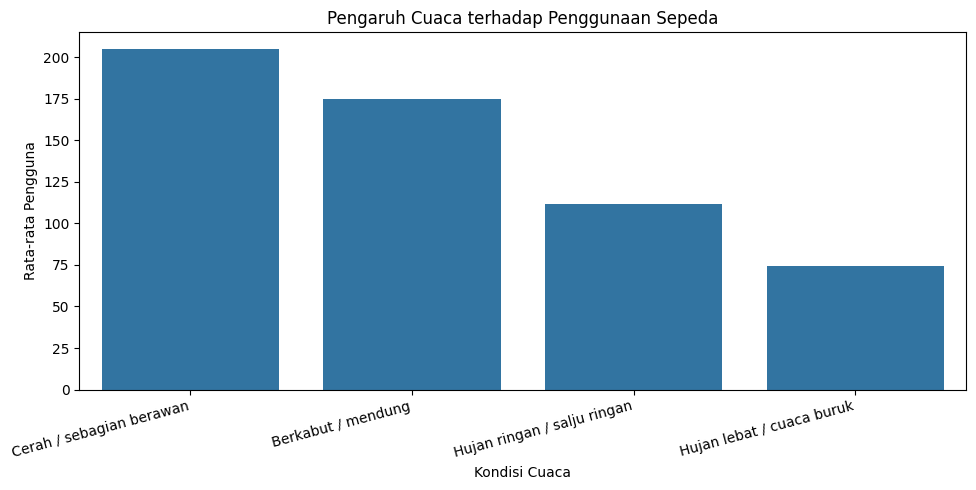

In [26]:
weather_map = {
    1: 'Cerah / sebagian berawan',
    2: 'Berkabut / mendung',
    3: 'Hujan ringan / salju ringan',
    4: 'Hujan lebat / cuaca buruk'
}

weather_usage = hour_df.groupby('weathersit')['cnt'].mean().reindex([1, 2, 3, 4])
weather_labels = [weather_map[i] for i in weather_usage.index]

plt.figure(figsize=(10, 5))
sns.barplot(x=weather_labels, y=weather_usage.values)
plt.title('Pengaruh Cuaca terhadap Penggunaan Sepeda')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Pengguna')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

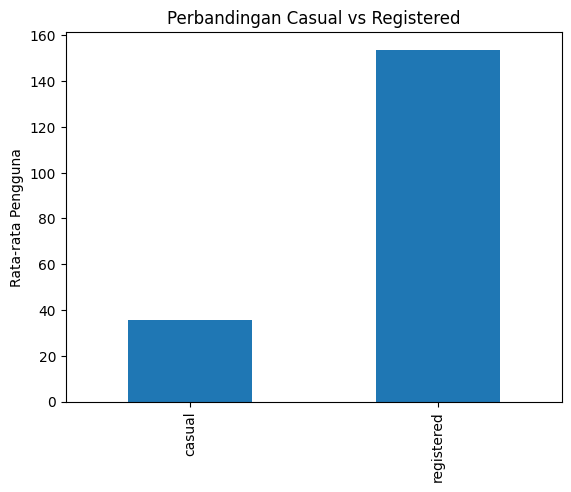

In [27]:
user_type = hour_df[['casual', 'registered']].mean()

user_type.plot(kind='bar')
plt.title('Perbandingan Casual vs Registered')
plt.ylabel('Rata-rata Pengguna')
plt.show()

**Insight:**

- Penggunaan sepeda paling rendah terjadi pada dini hari, lalu naik tajam pada pagi hari dan kembali mencapai puncak pada sore hingga malam awal.
- Rata-rata penggunaan pada hari kerja sedikit lebih tinggi dibanding hari libur.
- Semakin buruk kondisi cuaca, rata-rata penyewaan sepeda cenderung menurun.
- Pengguna registered jauh lebih banyak dibanding casual, sehingga mayoritas penyewaan datang dari pengguna yang sudah terdaftar.


## Analisis Lanjutan (Opsional)


## Conclusion


- Rata-rata penggunaan sepeda paling tinggi terjadi pada jam berangkat dan pulang kerja, bukan pada tengah hari.
- Hari kerja memiliki rata-rata penggunaan sedikit lebih tinggi daripada hari libur.
- Kondisi cuaca yang lebih buruk berkaitan dengan penurunan rata-rata penyewaan sepeda.
- Pengguna registered mendominasi jauh dibanding pengguna casual.
